# Notebook 02 — Data Pipeline & Preprocessing

**Project:** Cat vs Dog Image Classification: A Comparative Deep Learning Study

**Goal of this notebook:** take the approved file list from Notebook 01 (`clean_manifest.csv`) and
turn it into ready-to-train TensorFlow datasets: split into train/validation/test, load images,
resize them, batch them, and prefetch them.

No model, no CNN layers, no training, and no augmentation here — those come in later notebooks.


## 1. Setup

**What are we doing?** Importing what we need and fixing a random seed.

**Why are we doing it?** A fixed seed makes the split and shuffling reproducible — re-running this
notebook should give the same train/val/test split every time.


In [16]:
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings(
    "ignore", message="Truncated File Read", category=UserWarning
)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Notebook 01 saved the manifest next to the PetImages folder. Edit this path if needed.
MANIFEST_PATH = Path("clean_manifest.csv")

IMG_SIZE = (180, 180)
BATCH_SIZE = 32
CLASS_NAMES = {0: "Cat", 1: "Dog"}

print("Manifest path:", MANIFEST_PATH)


Manifest path: clean_manifest.csv


## 2. Load the Clean Manifest

**What are we doing?** Loading `clean_manifest.csv` and checking it looks correct.

**Why are we doing it?** Notebook 01 already audited the dataset and decided which files are
usable. Re-scanning the original folders here would risk picking up a different set of files (or
redoing work we already did). The manifest is our single source of truth for this notebook.


In [17]:
manifest_df = pd.read_csv(MANIFEST_PATH)

print("Shape:", manifest_df.shape)
manifest_df.head()


Shape: (24966, 3)


,filepath,class_name,label
0,PetImages_RGB\Cat\0.jpg,Cat,0
1,PetImages_RGB\Cat\1.jpg,Cat,0
2,PetImages_RGB\Cat\10.jpg,Cat,0
3,PetImages_RGB\Cat\100.jpg,Cat,0
4,PetImages_RGB\Cat\1000.jpg,Cat,0


In [18]:
assert set(["filepath", "class_name", "label"]).issubset(manifest_df.columns), "Manifest is missing expected columns"

print(manifest_df["class_name"].value_counts())


class_name
Dog    12486
Cat    12480
Name: count, dtype: int64


In [19]:
# Official Notebook 01 audit results -- confirms this run is using the same approved,
# normalized manifest, not a stale or regenerated one.
EXPECTED_ROWS = 24_966
EXPECTED_CAT = 12_480
EXPECTED_DOG = 12_486

actual_counts = manifest_df["class_name"].value_counts()

assert len(manifest_df) == EXPECTED_ROWS, f"Expected {EXPECTED_ROWS} rows, got {len(manifest_df)}"
assert actual_counts.get("Cat", 0) == EXPECTED_CAT, f"Expected {EXPECTED_CAT} Cat images, got {actual_counts.get('Cat', 0)}"
assert actual_counts.get("Dog", 0) == EXPECTED_DOG, f"Expected {EXPECTED_DOG} Dog images, got {actual_counts.get('Dog', 0)}"

print("Manifest matches Notebook 01's official audit results.")


Manifest matches Notebook 01's official audit results.


In [20]:
# Confirm every file the manifest points to still exists on disk.
files_exist = manifest_df["filepath"].apply(lambda p: Path(p).exists())
assert files_exist.all(), f"{(~files_exist).sum()} file(s) in the manifest are missing on disk"

print("All manifest files exist on disk.")


All manifest files exist on disk.


## 3. Train / Validation / Test Split

**What are we doing?** Splitting the manifest into three parts: 80% train, 10% validation,
10% test — stratified so Cat/Dog stay balanced in each split.

**Why are we doing it?**
- **Train** — the images the model actually learns from.
- **Validation** — used while developing the model (e.g. comparing experiments in later notebooks).
- **Test** — held out from all training and model-selection decisions. It is used exactly
  once for the final quantitative evaluation (Notebook 06), and afterward only for a post-hoc
  error analysis (Notebook 07) that does not feed back into the model. It must stay untouched
  during model development, so we set it aside now.

Stratifying keeps the Cat/Dog ratio consistent across all three splits — otherwise a random split
could accidentally put more cats in training and more dogs in validation, for example.


In [21]:
# First split off the test set (10%), then split the rest into train (80%) and validation (10%).
train_df, temp_df = train_test_split(
    manifest_df,
    test_size=0.2,
    stratify=manifest_df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))


Train: 19972
Val:   2497
Test:  2497


## 4. Check the Split

**What are we doing?** Confirming the split is balanced and leakage-free.

**Why are we doing it?** If the same image ended up in two splits, or one split had no cats at
all, any results from later notebooks would be untrustworthy. These checks catch that now.


In [22]:
for name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = split_df["class_name"].value_counts()
    percentages = (counts / len(split_df) * 100).round(1)
    print(f"{name}: {len(split_df)} images")
    print(counts)
    print(percentages.astype(str) + "%")
    print()


Train: 19972 images
class_name
Dog    9988
Cat    9984
Name: count, dtype: int64
class_name
Dog    50.0%
Cat    50.0%
Name: count, dtype: str

Val: 2497 images
class_name
Dog    1249
Cat    1248
Name: count, dtype: int64
class_name
Dog    50.0%
Cat    50.0%
Name: count, dtype: str

Test: 2497 images
class_name
Dog    1249
Cat    1248
Name: count, dtype: int64
class_name
Dog    50.0%
Cat    50.0%
Name: count, dtype: str



In [23]:
# No empty split, both classes present in every split
for split_df in [train_df, val_df, test_df]:
    assert len(split_df) > 0, "A split is empty"
    assert set(split_df["class_name"].unique()) == {"Cat", "Dog"}, "A split is missing a class"

# No duplicated filepath inside a split
for split_df in [train_df, val_df, test_df]:
    assert split_df["filepath"].is_unique, "Duplicate filepath found inside a split"

# No filepath appears in more than one split (no leakage between splits)
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

assert train_paths.isdisjoint(val_paths), "Train/validation overlap found"
assert train_paths.isdisjoint(test_paths), "Train/test overlap found"
assert val_paths.isdisjoint(test_paths), "Validation/test overlap found"

print("All split checks passed — no leakage between train/val/test.")


All split checks passed — no leakage between train/val/test.


## 5. Image Loading

**What are we doing?** Writing one small function that reads an image file, decodes it, and
resizes it to a fixed size (180 x 180).

**Why are we doing it?**
- Images in the dataset come in many different sizes — a CNN needs every input to be the same size.
- Reading as RGB guarantees 3 color channels for every image, even if a few were grayscale.
- We are not normalizing pixel values here — that choice is simple enough to make later, closer to
  the model itself (Notebook 03), so this function stays a pure "load and resize" step.


In [24]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)   # channels=3 forces RGB
    image = tf.image.resize(image, IMG_SIZE)
    return image, label


## 6. Build tf.data Datasets

**What are we doing?** Turning each split's filepaths and labels into a `tf.data.Dataset`, then
applying `load_image` to every entry.

**Why are we doing it?** `tf.data.Dataset.from_tensor_slices` lets TensorFlow load images lazily,
one at a time, instead of loading all 25,000 images into memory at once. We shuffle only the
training set — validation and test should stay in a fixed, predictable order.

No augmentation is added here — that belongs to Notebook 04.


In [25]:
def make_dataset(split_df, shuffle=False):
    filepaths = split_df["filepath"].values
    labels = split_df["label"].values

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(split_df), seed=SEED)
    ds = ds.map(load_image)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Datasets created.")


Datasets created.


## 7. Batch the Data

**What are we doing?** Grouping images into batches of 32.

**Why are we doing it?** Instead of sending all images to the model at once, we send them in
smaller groups of 32. This is both memory-friendly and how gradient updates normally work during
training.


In [26]:
train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

print(f"Batched with BATCH_SIZE = {BATCH_SIZE}")


Batched with BATCH_SIZE = 32


## 8. Prefetch

**What are we doing?** Adding `.prefetch(tf.data.AUTOTUNE)` to each dataset.

**Why are we doing it?** Prefetching lets TensorFlow prepare the next batch (reading and decoding
images) while the current batch is still being processed, instead of waiting idly. `AUTOTUNE` lets
TensorFlow pick a sensible buffer size automatically.


In [27]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("Prefetching enabled on all three datasets.")


Prefetching enabled on all three datasets.


## 9. Inspect the Pipeline

**What are we doing?** Pulling one batch out of `train_ds` and checking its shape and contents.

**Why are we doing it?** This is a quick sanity check before moving on — if the shapes or label
values look wrong here, it's much easier to fix now than after building a model on top of it.


In [28]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
print("Unique label values in this batch:", np.unique(labels.numpy()))

assert images.shape[1:3] == IMG_SIZE, "Unexpected image size"
assert images.shape[-1] == 3, "Expected 3 color channels"
assert set(np.unique(labels.numpy())).issubset({0, 1}), "Unexpected label value found"

print("Pipeline shapes look correct.")


Image batch shape: (32, 180, 180, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int64'>
Unique label values in this batch: [0 1]
Pipeline shapes look correct.


## 10. Visualize Images

**What are we doing?** Displaying a few images from the training batch with their class name.

**Why are we doing it?** Numbers and shapes can look correct while something is still subtly wrong
(e.g. a mismatched label). Actually looking at a handful of images next to their label is the
simplest way to confirm the pipeline is doing what we think it's doing.


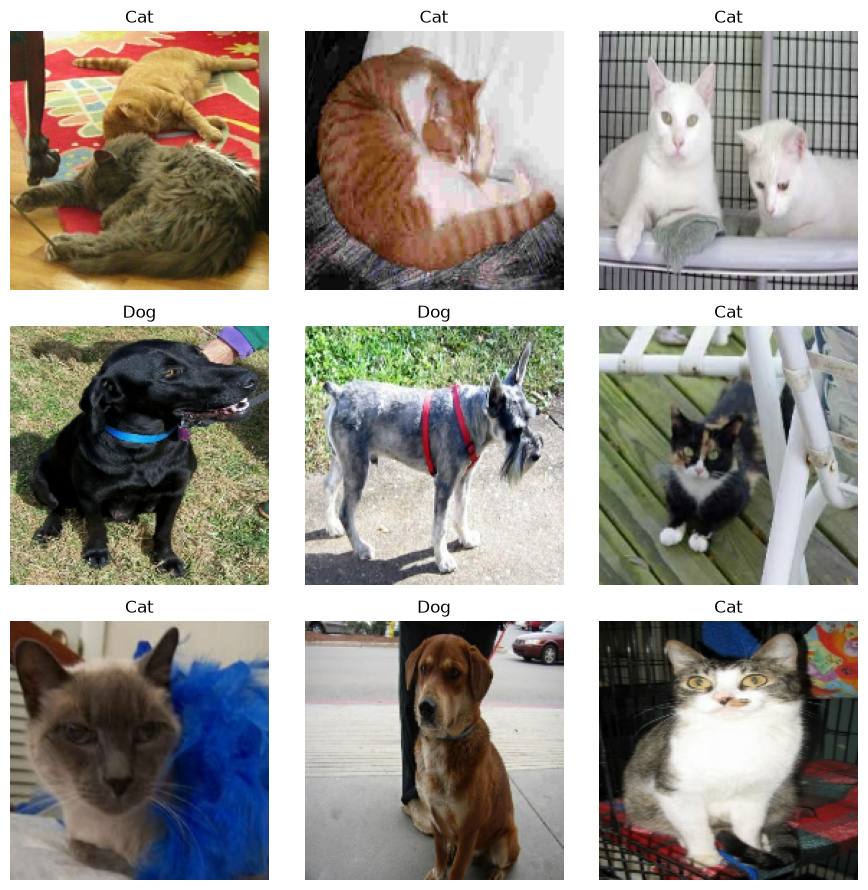

In [29]:
plt.figure(figsize=(9, 9))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(CLASS_NAMES[int(labels[i].numpy())])
    plt.axis("off")
plt.tight_layout()
plt.show()


## 11. Final Pipeline Summary


In [30]:
summary = {
    "Total samples": len(manifest_df),
    "Training samples": len(train_df),
    "Validation samples": len(val_df),
    "Test samples": len(test_df),
    "Image size": f"{IMG_SIZE[0]}x{IMG_SIZE[1]}",
    "Channels": 3,
    "Batch size": BATCH_SIZE,
    "Number of classes": 2,
}
pd.Series(summary, name="Value").to_frame()


,Value
Total samples,24966
Training samples,19972
Validation samples,2497
Test samples,2497
Image size,180x180
Channels,3
Batch size,32
Number of classes,2


**Conclusion:** the cleaned dataset from Notebook 01 has been split into train/validation/test
sets (80/10/10, stratified, leakage-checked), loaded and resized to 180x180 RGB images, batched,
and prefetched. `train_ds`, `val_ds`, and `test_ds` are ready to be used by Notebook 03 to build and
train a baseline CNN.
